## Section A

In [5]:
# Question 2
import pandas as pd
data=pd.read_csv('froyo.csv')

data.isna().sum()>=1

id                       False
quality                  False
variety                  False
price                    False
distance                 False
courteousness            False
atmosphere               False
rating_PinkBerry         False
rating_RedMango          False
rating_16Handles         False
rank_PinkBerry           False
rank_RedMango            False
rank_16Handles           False
rewardsCard_16Handles    False
social                   False
gender                   False
dtype: bool

In [10]:
# Question 4
from sklearn.preprocessing import StandardScaler
needs_vars = [
    "quality",
    "variety",
    "price",
    "distance",
    "courteousness",
    "atmosphere"
]

scaler = StandardScaler()
froyo_scaled = pd.DataFrame(
    scaler.fit_transform(data[needs_vars]),
    columns=needs_vars
)

# Standardized value of quality for the first observation
froyo_scaled.loc[0, "quality"]

np.float64(-1.1279058173719143)

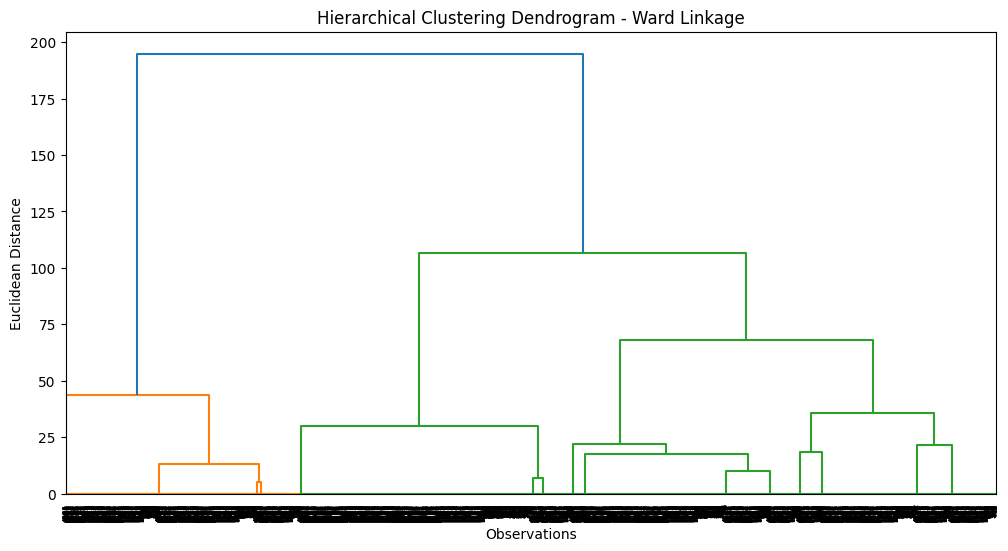

In [11]:
# Question 6
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
# Compute Euclidean distance between all observations
distance_matrix = pdist(froyo_scaled, metric="euclidean")

# Hierarchical clustering using Ward linkage
linked = linkage(distance_matrix, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Observations")
plt.ylabel("Euclidean Distance")
plt.show()


In [14]:
# Question 8
from scipy.cluster.hierarchy import cophenet
# Cophenetic correlation coefficient
coph_corr, coph_distances = cophenet(linked, distance_matrix)

coph_corr

np.float64(0.8922210863522106)

In [19]:
# Question 10
from scipy.cluster.hierarchy import fcluster
# Create 3-cluster solution
cluster_labels = fcluster(linked, t=3, criterion="maxclust")

# Add cluster labels to original data
data["cluster_3"] = cluster_labels

# Count observations in each cluster
cluster_counts = data["cluster_3"].value_counts().sort_index()


# Largest cluster size
largest_cluster_size = cluster_counts.max()

largest_cluster_size

np.int64(2273)

In [20]:
# Question 12
froyo=data.copy()
rating_vars = [
    "rating_PinkBerry",
    "rating_RedMango",
    "rating_16Handles"
]

# Average restaurant ratings by cluster
cluster_rating_means = froyo.groupby("cluster_3")[rating_vars].mean()

# Cluster 1 ratings
cluster_1_ratings = cluster_rating_means.loc[1]

# Restaurant rated lowest by Cluster 1
answer = cluster_1_ratings.idxmin()

print(cluster_rating_means)
print(answer)

           rating_PinkBerry  rating_RedMango  rating_16Handles
cluster_3                                                     
1                  2.575949         2.011076          1.808544
2                  2.000000         5.000000          5.000000
3                  3.229212         3.783106          3.783986
rating_16Handles


## Section C

In [ ]:
# Question 32
import pandas as pd

amazon = pd.read_csv("amazon.csv", parse_dates=["date"], index_col=["date"]).asfreq("ME")

test = amazon.iloc[-24:]
train = amazon.iloc[:-24]

print(len(train))

216


In [23]:
# Question 34
answer = train.loc["2016-01":"2020-12", "price"].mean()

print(answer)

78.73484099706015


In [26]:
# Question 36
amazon["monthly_pct_change"] = amazon["price"].pct_change() * 100

answer = amazon.loc["2019-12", "monthly_pct_change"].iloc[0]

print(answer)

2.6121694264473083


In [27]:
# Question 38
import numpy as np
from statsmodels.tsa.stattools import adfuller

amazon["log_price"] = np.log(amazon["price"])

log_price_diff = amazon["log_price"].diff().dropna()

adf_result = adfuller(log_price_diff)

print(adf_result[1])

if adf_result[1] < 0.05:
    print("First order difference of log_price is stationary")
else:
    print("First order difference of log_price is not stationary")

1.0792355060641316e-28
First order difference of log_price is stationary


In [29]:
# Question 40
from statsmodels.tsa.statespace.sarimax import SARIMAX

train["log_price"] = np.log(train["price"])

# Model specifications
model_specs = [
    ((5, 1, 5), (0, 0, 0, 12)),
    ((0, 1, 0), (0, 0, 0, 12)),
    ((3, 1, 3), (2, 1, 2, 12)),
    ((2, 1, 2), (0, 0, 0, 12))
]

aic_results = {}

for order, seasonal_order in model_specs:
    model = SARIMAX(
        train["log_price"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False)
    aic_results[(order, seasonal_order)] = result.aic

print(aic_results)

answer = max(aic_results, key=aic_results.get)

print(answer)
print(aic_results[answer])

c:\Users\athar\anaconda4\envs\DataScienceForBusiness\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\athar\anaconda4\envs\DataScienceForBusiness\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{((5, 1, 5), (0, 0, 0, 12)): np.float64(-345.8477482811504), ((0, 1, 0), (0, 0, 0, 12)): np.float64(-361.8743989494842), ((3, 1, 3), (2, 1, 2, 12)): np.float64(-296.5949161766464), ((2, 1, 2), (0, 0, 0, 12)): np.float64(-357.05242583532174)}
((3, 1, 3), (2, 1, 2, 12))
-296.5949161766464


In [30]:
# Question 42
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["log_price"],
    order=(0, 1, 0),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print(result.aic)

-361.8743989494842


In [38]:
# Question 44

import numpy as np

forecast_log = result.get_forecast(steps=len(test))

forecast_price = np.exp(forecast_log.predicted_mean)

answer = forecast_price.loc[test.index[-1]]

print(answer)

83.99999999999999


In [39]:
# Question 46
# Forecast for the full test period
forecast_log = result.get_forecast(steps=len(test))

# Convert forecast from log scale back to price scale
forecast_price = np.exp(forecast_log.predicted_mean)

# RMSE in test sample
rmse = np.sqrt(np.mean((test["price"] - forecast_price) ** 2))

print(rmse)

78.88085318013536


## Section D

In [40]:
# Question 49
import pandas as pd
import networkx as nx

node_df = pd.read_csv("exam_network_analysis_employees.csv", index_col="employee")
edge_df = pd.read_csv("exam_network_analysis_collaborations.csv")

G = nx.from_pandas_edgelist(
    edge_df,
    source="source",
    target="target",
    edge_attr=True
)

nx.set_node_attributes(G, node_df.to_dict(orient="index"))

answer = G.number_of_edges()

print(answer)

130


In [41]:
# Question 51
print(edge_df["project_type"].unique())

<StringArray>
['training', 'internal', 'client']
Length: 3, dtype: str


In [42]:
# Question 53
answer = nx.density(G)

print(answer)

0.11054421768707483


In [43]:
# Question 55
options = ["Denise", "Erika", "Claudia", "Bridget"]

closeness = nx.closeness_centrality(G)

for employee in options:
    print(employee, closeness[employee])

answer = max(options, key=lambda x: closeness[x])

print(answer)

Denise 0.3333333333333333
Erika 0.46601941747572817
Claudia 0.48484848484848486
Bridget 0.42857142857142855
Claudia


In [44]:
# Question 57
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

community_sizes = [len(c) for c in communities]

answer = max(community_sizes)

print(community_sizes)
print(answer)

[13, 11, 9, 8, 8]
13


In [45]:
# Question 59
pairs = [
    ("Dawn", "Jake"),
    ("Christopher", "Sean"),
    ("Erika", "William"),
    ("Claudia", "David")
]

scores = list(nx.jaccard_coefficient(G, pairs))

for u, v, score in scores:
    print(u, v, score)

answer = max(scores, key=lambda x: x[2])

print(answer)

Dawn Jake 0.14285714285714285
Christopher Sean 0.125
Erika William 0.125
Claudia David 0.1111111111111111
('Dawn', 'Jake', 0.14285714285714285)


In [46]:
# Question 61
score = list(nx.jaccard_coefficient(G, [("Michelle", "Alejandro")]))

print(score)
print(score[0][2])

[('Michelle', 'Alejandro', 0.0)]
0.0
